COM ELITISMO
Rota: [6 4 7 2 5 3 0 1]
Custo: 250.37

SEM ELITISMO
Rota: [5 7 1 6 4 0 3 2]
Custo: 272.22


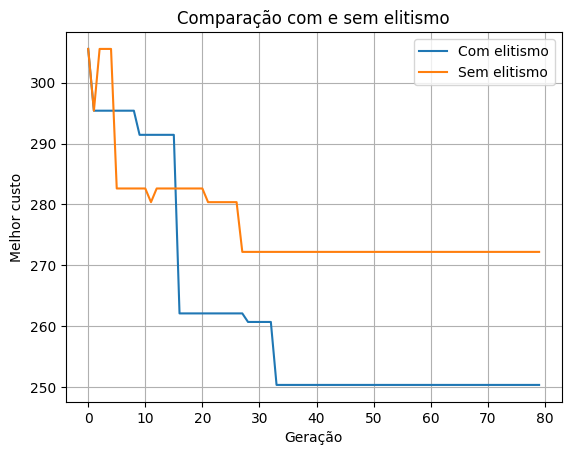

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(2026)

NUM_NOS = 8
TAM_POP = 40
GERACOES = 80

matriz = np.random.uniform(10, 100, (NUM_NOS, NUM_NOS))
np.fill_diagonal(matriz, 0)

def calcular_custo(rota):
    custo = sum(matriz[rota[i], rota[i+1]] for i in range(len(rota)-1))
    return custo + matriz[rota[-1], rota[0]]

def executar(usar_elitismo):
    populacao = [np.random.permutation(NUM_NOS) for _ in range(TAM_POP)]
    historico = []

    for _ in range(GERACOES):
        custos = [calcular_custo(ind) for ind in populacao]
        melhor = np.argmin(custos)
        historico.append(custos[melhor])

        novos = []

        if usar_elitismo:
            novos.append(populacao[melhor].copy())

        while len(novos) < TAM_POP:
            i1, i2 = np.random.choice(TAM_POP, 2, replace=False)
            pai = populacao[i1] if custos[i1] < custos[i2] else populacao[i2]

            filho = pai.copy()

            if np.random.rand() < 0.3:
                a, b = np.random.choice(NUM_NOS, 2, replace=False)
                filho[a], filho[b] = filho[b], filho[a]

            novos.append(filho)

        populacao = novos

    custos = [calcular_custo(ind) for ind in populacao]
    melhor = np.argmin(custos)

    return populacao[melhor], custos[melhor], historico


# Com elitismo
np.random.seed(2026)
rota_com, custo_com, hist_com = executar(True)

# Sem elitismo
np.random.seed(2026)
rota_sem, custo_sem, hist_sem = executar(False)

print("COM ELITISMO")
print("Rota:", rota_com)
print(f"Custo: {custo_com:.2f}")

print("\nSEM ELITISMO")
print("Rota:", rota_sem)
print(f"Custo: {custo_sem:.2f}")

plt.plot(hist_com, label="Com elitismo")
plt.plot(hist_sem, label="Sem elitismo")

plt.xlabel("Geração")
plt.ylabel("Melhor custo")
plt.title("Comparação com e sem elitismo")
plt.legend()
plt.grid()

plt.show()
